In [3]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist,plot_residuals

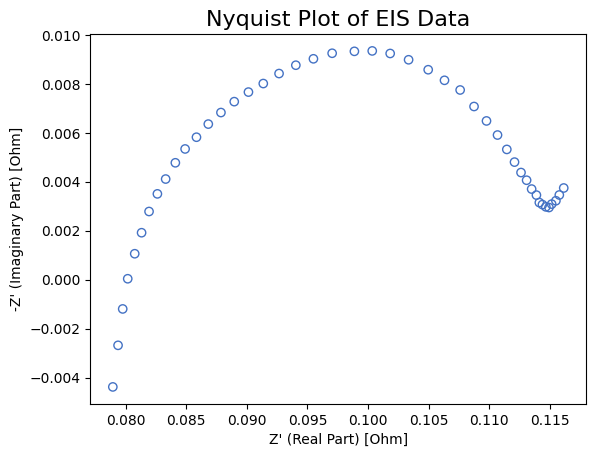

In [19]:
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']
base_file = './LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_2/EIS_Charge_discharge/EIS_140/4_EIS.csv'

# Read the CSV file
dataset = pd.read_csv(
    base_file,
    header=None,  # Specify that there is no header row
    names=col_names,
    sep='\t'  # Apply your defined column names
)

# The rest of your code now works without modification
f_x = dataset['Frequency(Hz)'].values  # Frequency in Hz
R = dataset['R(ohm)'].values 
X = dataset['X(ohm)'].values
Z = R + 1j * X
Z_abs = np.abs(Z)
logx = np.logspace(0, 4, 5001)

# You can uncomment this line to check if the data loaded correctly
# print(dataset.head())
# plt.xlim(0.075, 0.125)
# plt.ylim(-0.005, 0.012)
# plot_nyquist(Z)
# plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(Z.real, -Z.imag, edgecolor='#4472C4', facecolor='None', marker='o', label='Sample')
plt.title("Nyquist Plot of EIS Data", fontsize=16)
plt.xlabel("Z' (Real Part) [Ohm]", fontsize=10)
plt.ylabel("-Z' (Imaginary Part) [Ohm]", fontsize=10)
plt.show()
# fig = plt.figure(figsize=(10,4), dpi=150)
# # plt.scatter(Z.real, -Z.imag, edgecolor='black', facecolor='None', marker='D', label='Sample')
# plt.scatter(Z.real, -Z.imag,  color='#4472C4', marker='o')
# plt.gca().set_aspect('equal', adjustable='box')
# plt.legend(fontsize=12)
# plt.title("Nyquist plot", fontsize=14)
# plt.xlabel("Z' (Real Part) [Ohm]")
# plt.ylabel("-Z' (Imaginary Part) [Ohm]")

--- Model 1 ('L1-R0-p(R1,CPE1)-W1') Fit ---

Circuit string: L1-R0-p(R1,CPE1)-W1
Fit: True

Initial guesses:
     L1 = 1.00e-01 [H]
     R0 = 1.00e-01 [Ohm]
     R1 = 5.00e+01 [Ohm]
  CPE1_0 = 1.00e-05 [Ohm^-1 sec^a]
  CPE1_1 = 9.00e-01 []
     W1 = 1.00e+00 [Ohm sec^-1/2]

Fit parameters:
     L1 = 1.93e-07  (+/- 7.92e-09) [H]
     R0 = 7.79e-02  (+/- 2.20e-04) [Ohm]
     R1 = 3.79e-02  (+/- 4.30e-04) [Ohm]
  CPE1_0 = 9.08e-01  (+/- 3.55e-02) [Ohm^-1 sec^a]
  CPE1_1 = 5.78e-01  (+/- 7.87e-03) []
     W1 = 2.00e-03  (+/- 2.40e-04) [Ohm sec^-1/2]


--- Model 2 ('R0-p(R1,CPE1)') Fit ---

Circuit string: R0-L0-p(R1,CPE1)-p(R2,CPE2)-W1
Fit: True

Initial guesses:
     R0 = 1.00e-01 [Ohm]
     L0 = 1.00e-07 [H]
     R1 = 5.00e+01 [Ohm]
  CPE1_0 = 1.00e-05 [Ohm^-1 sec^a]
  CPE1_1 = 9.00e-01 []
     R2 = 2.00e+02 [Ohm]
  CPE2_0 = 1.00e-05 [Ohm^-1 sec^a]
  CPE2_1 = 9.00e-01 []
     W1 = 1.00e+00 [Ohm sec^-1/2]

Fit parameters:
     R0 = 7.76e-02  (+/- 2.18e-04) [Ohm]
     L0 = 1.97e-07  (+/- 6

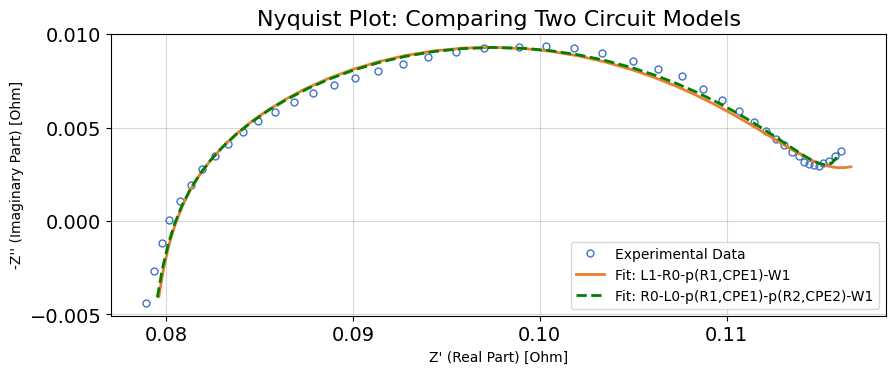

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist
import warnings

# --- Setup ---
# This script assumes you have your frequency (f_x) and impedance (Z)
# variables already loaded in memory from your previous cells.
# For example:
# f_x = df['Frequency(Hz)'].values
# R = df['R(ohm)'].values
# X = df['X(ohm)'].values
# Z = R + 1j * X

# --- Dummy Data (if you want to run this script standalone) ---
# (Comment this out if you have f_x and Z loaded)
if 'f_x' not in locals() or 'Z' not in locals():
    print("Warning: f_x and Z not found. Using dummy data.")
    f_x = np.logspace(-2, 5, 100)
    Z_true = 0.1 + (1j*2*np.pi*f_x*1e-7) + 50 / (1 + (1j*2*np.pi*f_x*1e-5)**0.9)
    # Add noise
    Z = Z_true + np.random.normal(0, 0.5, Z_true.shape) + 1j*np.random.normal(0, 0.5, Z_true.shape)
# --- End of Dummy Data ---


# --- 1. Define and Fit Model 1 ---
circuit_1_str = 'L1-R0-p(R1,CPE1)-W1'
guess_1 = [0.1, 0.1, 50, 1e-5, 0.9, 1]

# Suppress warnings if the fit isn't perfect
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_1 = CustomCircuit(initial_guess=guess_1, circuit=circuit_1_str)
    model_1.fit(f_x, Z)
Z_fit_1 = model_1.predict(f_x)

print("--- Model 1 ('L1-R0-p(R1,CPE1)-W1') Fit ---")
print(model_1)


# --- 2. Define and Fit Model 2 ---
circuit_2_str = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)-W1' # 9-parameter model
# R0, L0, R1, CPE1_0, CPE1_1, R2, CPE2_0, CPE2_1, W1
guess_2 = [0.1, 1e-7, 50, 1e-5, 0.9, 200, 1e-5, 0.9, 1] # Note: 4 parameters for this 4-element circuit

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_2 = CustomCircuit(initial_guess=guess_2, circuit=circuit_2_str)
    model_2.fit(f_x, Z)
Z_fit_2 = model_2.predict(f_x)

print("\n--- Model 2 ('R0-p(R1,CPE1)') Fit ---")
print(model_2)


# --- 3. Plot the Comparison ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the Experimental Data (as points)
# --- FIX: Swapped ax and Z, and passed ax as keyword ---
plot_nyquist(Z, ax=ax, fmt='o', markersize=5, markerfacecolor='None', 
             markeredgecolor='#4472C4', label='Experimental Data')

# Plot the Fit from Model 1 (as a solid line)
# --- FIX: Swapped ax and Z_fit_1, and passed ax as keyword ---
plot_nyquist(Z_fit_1, ax=ax, fmt='-', color='#ED7D31', lw=2, 
             label=f'Fit: {circuit_1_str}')

# Plot the Fit from Model 2 (as a dashed line)
# --- FIX: Swapped ax and Z_fit_2, and passed ax as keyword ---
plot_nyquist(Z_fit_2, ax=ax, fmt='--', color='green', lw=2, 
             label=f'Fit: {circuit_2_str}')

# 4. Customize the plot
ax.legend()
ax.grid(True)
ax.set_title("Nyquist Plot: Comparing Two Circuit Models", fontsize=16)
ax.set_xlabel("Z' (Real Part) [Ohm]", fontsize=10)
ax.set_ylabel("-Z'' (Imaginary Part) [Ohm]", fontsize=10)
ax.set_aspect('equal') # Ensure the plot is square

plt.show()

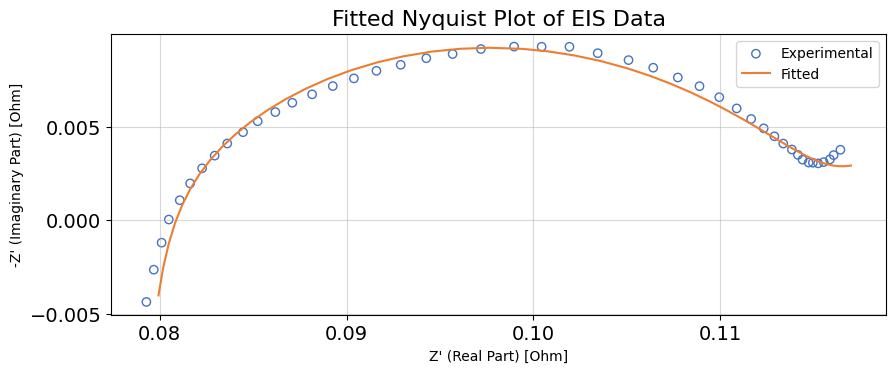

In [ ]:
# !pip install impedance

# Define the modified circuit string
# circuit = 'R0-p(R1-CPE1)-p(R2-W1,CPE2)'
# circuit,initial_guess = 'L1-R0-p(R1,CPE1)-p(R2-W1,CPE2)',[0.1,0.1, 0.04, 1e-5, 0.9, 200, 1e-5, 0.9, 1]  # Try 1
# circuit,initial_guess = 'R0-p(R1,CPE1)',[0.1, 0.04, 1e-5, 0.9]  # Try 2
# circuit,initial_guess = 'R0-p(R1,CPE1)-W1',[0.1, 0.04, 1e-5, 0.9, 1]  # Try 3
circuit,initial_guess = 'L1-R0-p(R1,CPE1)-W1',[0.1,0.1, 50, 1e-5, 0.9, 1]  # Try 4

# Create the circuit model
circuit_model = CustomCircuit(initial_guess=initial_guess, circuit=circuit)
circuit_model.fit(f_x, Z)

# Plot the fitted circuit model
fig, ax = plt.subplots(figsize=(10, 10))
# plot_nyquist(Z, ax=ax)
plt.scatter(Z.real, -Z.imag, edgecolor='#4472C4', facecolor='None', marker='o', label='Sample')
plot_nyquist(circuit_model.predict(f_x), ax=ax, fmt='-', color='#ED7D31')
ax.legend(['Experimental', 'Fitted'])
plt.grid(True)
plt.title("Fitted Nyquist Plot of EIS Data", fontsize=16)
plt.xlabel("Z' (Real Part) [Ohm]", fontsize=10)
plt.ylabel("-Z' (Imaginary Part) [Ohm]", fontsize=10)
plt.show()

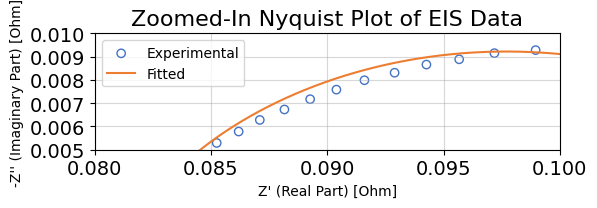

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Z.real, -Z.imag, edgecolor='#4472C4', facecolor='None', marker='o', label='Sample')
plot_nyquist(circuit_model.predict(logx), ax=ax, fmt='-',color='#ED7D31')
ax.legend(['Experimental', 'Fitted'])
plt.grid(True)

# ⬇️ Add these lines to zoom in
ax.set_xlim(0.08, 0.1)    # Real part of impedance (Z')
ax.set_ylim(0.005, 0.01)    # Imaginary part of impedance (-Z'')

plt.title("Zoomed-In Nyquist Plot of EIS Data", fontsize=16)
plt.xlabel("Z' (Real Part) [Ohm]", fontsize=10)
plt.ylabel("-Z'' (Imaginary Part) [Ohm]", fontsize=10)
plt.show()

In [7]:
#Fitting Errors
Z_fit = circuit_model.predict(f_x)
error = np.abs(Z - Z_fit)
rmse = np.sqrt(np.mean(np.square(error)))
mean_absolute_error = np.mean((error))
max_error = np.max(error)
weighted_error = (Z - Z_fit) / np.abs(Z)

chi_squared = np.sum(weighted_error.real**2) + np.sum(weighted_error.imag**2)
# print(f"Chi-Squared: {chi_squared:.4e}")
# print(f"RMSE: {rmse:.4e}")
# print(f"Mean Absolute Error: {mean_absolute_error:.4e}")
# print(f"Max Error: {max_error:.4e}")
df_metrics = pd.DataFrame({
    'Error Metric': ['Chi-Squared', 'RMSE', 'Mean Absolute Error', 'Max Error'],
    'Value': [chi_squared, rmse, mean_absolute_error, max_error]
}).reset_index(drop=True)
df_metrics.style.hide(axis='index')


Error Metric,Value
Chi-Squared,0.001095
RMSE,0.000489
Mean Absolute Error,0.000468
Max Error,0.001016


<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
/var/folders/tf/yj0t6lyd7dz7mpbkbq4_c1rw0000gn/T/ipykernel_39342/3568541894.py:12: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel("Residual Error ($\Omega$)", fontsize=10) # Y-axis should be the error


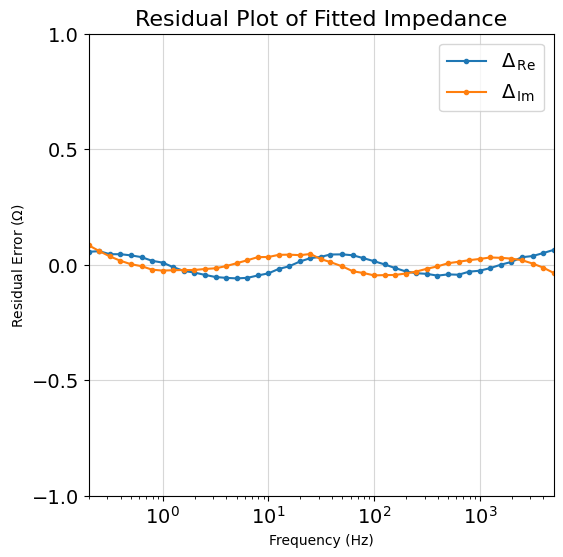

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

# This line is correct, assuming plot_residuals is defined
plot_residuals(ax, f_x, (Z_fit-Z).real, (Z_fit-Z).imag, y_limits=(-1, 1))

# --- Fixes Below ---
# Use ax.set_... instead of plt....
# And swap the x and y labels

ax.set_title("Residual Plot of Fitted Impedance", fontsize=16)
ax.set_xlabel("Frequency (Hz)", fontsize=10)  # X-axis should be frequency
ax.set_ylabel("Residual Error ($\Omega$)", fontsize=10) # Y-axis should be the error

plt.show()

In [9]:
# import pandas as pd
# import numpy as np

# --- Re-creating your variables ---
# (You already have these, so you can skip this part)
try:
    param_names = circuit_model.get_param_names()[0]
    param_values = circuit_model.parameters_
    param_errors = circuit_model.conf_
except:
    # Creating dummy data in case circuit_model isn't fitted
    raise NameError("circuit_model is not defined or not fitted.")
# --- End of variable creation ---


# --- 1. Calculate Percentage Error ---
percent_errors = (np.abs(param_errors) / np.abs(param_values)) * 100

# --- 2. Create the Status list ---
status_list = []
for perc_err in percent_errors:
    if perc_err > 50:
        status = "UNRELIABLE (>> 10%)"
    elif perc_err > 10:
        status = "Unreliable (> 10%)"
    elif perc_err > 5:
        status = "Acceptable (5-10%)"
    # elif perc_err > 2:
    #     status = "Excellent (2-5%)"
    else:
        status = "Excellent (< 5%)"
    status_list.append(status)

# --- 3. Create the Pandas DataFrame ---
data_dict = {
    'Parameter': param_names,
    'Fitted Value': param_values,
    'Error (%)': percent_errors,
    'Status': status_list
}
df_errors = pd.DataFrame(data_dict)

format_dict = {
    'Fitted Value': '{:.4e}',
    'Std. Error (%)': '{:.2f}%'
}
print("--- Parameter Standard Error Analysis ---")
df_errors.style.format(format_dict)

--- Parameter Standard Error Analysis ---


,Parameter,Fitted Value,Error (%),Status
0,L1,1.9262e-07,4.131650,Excellent (< 5%)
1,R0,7.8132e-02,0.287281,Excellent (< 5%)
2,R1,3.8085e-02,1.164528,Excellent (< 5%)
3,CPE1_0,9.5154e-01,3.939089,Excellent (< 5%)
4,CPE1_1,5.7170e-01,1.392085,Excellent (< 5%)
5,W1,1.9628e-03,12.435843,Unreliable (> 10%)


In [10]:
# After fitting
fitted_parameters = circuit_model.parameters_

# Extract parameter names
param_names = circuit_model.get_param_names()

nested_param_names = circuit_model.get_param_names()
param_names = [item for sublist in nested_param_names for item in (sublist if isinstance(sublist, list) else [sublist])]
params_dict = dict(zip(param_names, fitted_parameters))


# Print them
for name, value in params_dict.items():
    print(f"{name}: {value:.4g}")
params_df = pd.DataFrame([params_dict])
# params_df.to_csv('fitted_parameters.csv', index=False)

L1: 1.926e-07
R0: 0.07813
R1: 0.03808
CPE1_0: 0.9515
CPE1_1: 0.5717
W1: 0.001963


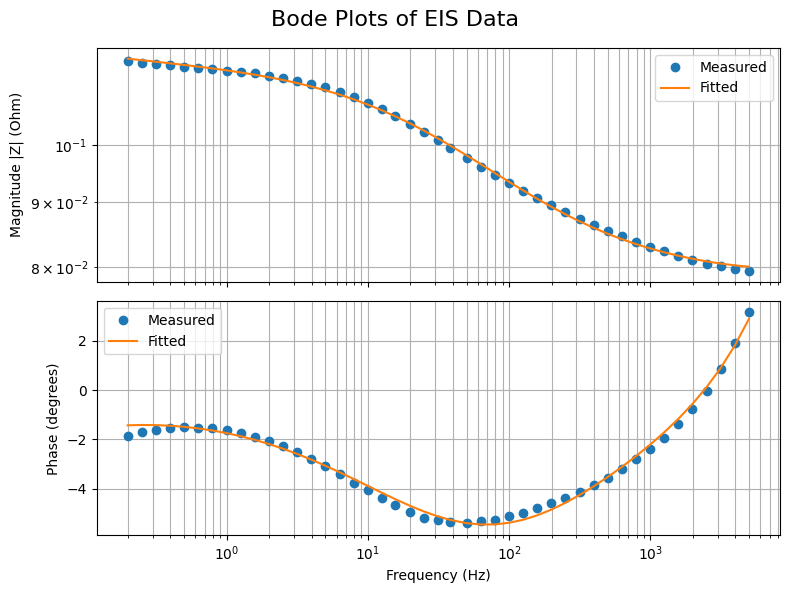

In [11]:
# Predict impedance from the fitted model
Z_fit = circuit_model.predict(f_x)

# Plot Bode plots: magnitude and phase vs frequency
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Magnitude plot (|Z|)
axs[0].loglog(f_x, np.abs(Z), 'o', label='Measured')
axs[0].loglog(f_x, np.abs(Z_fit), '-', label='Fitted')
axs[0].set_ylabel('Magnitude |Z| (Ohm)')
axs[0].legend()
axs[0].grid(True, which='both')

# Phase plot (in degrees)
axs[1].semilogx(f_x, np.angle(Z, deg=True), 'o', label='Measured')
axs[1].semilogx(f_x, np.angle(Z_fit, deg=True), '-', label='Fitted')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Phase (degrees)')
axs[1].legend()
axs[1].grid(True, which='both')

fig.suptitle("Bode Plots of EIS Data", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
# pip install impedance